In [1]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
import numpy as np
import pandas as pd
import pickle
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [2]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
def conv_array(df):
    x,y=df.drop('Class',axis=1),df['Class'].values
    x=x.values
    y0=np.ones(len(y),np.int8)
    y0[np.where(y=='normal')]=0
    y0[np.where(y=='dos')]=1
    y0[np.where(y=='r2l')]=2
    y0[np.where(y=='u2r')]=3
    y0[np.where(y=='probe')]=4
    return x,y,y0

# Function for saving trained models
def save_model(model, filename="model.sav"):
    try:
        # Save the model to the specified file
        with open(filename, 'wb') as file:
            pickle.dump(model, file)
        print(f"Model has been saved at: {filename}")
    except Exception as e:
        print(f"Error saving the model: {e}")

In [3]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
training_set_path = "datasets/KDDTrain.csv"
test_set_path = "datasets/KDDTest.csv"

training_df = pd.read_csv(training_set_path, header=None)
testing_df = pd.read_csv(test_set_path, header=None)

print("Training set has {} rows.".format(len(training_df)))
print("Testing set has {} rows.".format(len(testing_df)))

Training set has 125973 rows.
Testing set has 22543 rows.


In [4]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome', 'difficulty']
training_df.columns = columns
testing_df.columns = columns

In [ ]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb


In [5]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
dos_attacks=["snmpgetattack","back","land","neptune","smurf","teardrop","pod","apache2","udpstorm","processtable","mailbomb"]
r2l_attacks=["snmpguess","worm","httptunnel","named","xlock","xsnoop","sendmail","ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster"]
u2r_attacks=["sqlattack","buffer_overflow","loadmodule","perl","rootkit","xterm","ps"]
probe_attacks=["ipsweep","nmap","portsweep","satan","saint","mscan"]

# Helper function to label samples to 5 classes
def label_attack (row):
    if row["outcome"] in dos_attacks:
        return "dos"
    if row["outcome"] in r2l_attacks:
        return "r2l"
    if row["outcome"] in u2r_attacks:
        return "u2r"
    if row["outcome"] in probe_attacks:
        return "probe"                        
    return "normal"


# We combine the datasets temporarily to do the labeling 
test_samples_length = len(testing_df)
df=pd.concat([training_df,testing_df])
df["Class"]=df.apply(label_attack,axis=1)

# The old outcome field is dropped since it was replaced with the Class field, the difficulty field will be dropped as well.
df=df.drop("outcome",axis=1)
df=df.drop("difficulty",axis=1)

# We again split the data into training and test sets.
training_df= df.iloc[:-test_samples_length, :]
testing_df= df.iloc[-test_samples_length:,:]

In [10]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
testing_df.head(15)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Class
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,dos
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,dos
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,probe
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,probe
5,0,tcp,http,SF,267,14515,0,0,0,0,...,255,1.00,0.00,0.01,0.03,0.01,0.00,0.00,0.00,normal
6,0,tcp,smtp,SF,1022,387,0,0,0,0,...,28,0.11,0.72,0.00,0.00,0.00,0.00,0.72,0.04,normal
7,0,tcp,telnet,SF,129,174,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.01,0.01,0.02,0.02,r2l
8,0,tcp,http,SF,327,467,0,0,0,0,...,255,1.00,0.00,0.01,0.03,0.00,0.00,0.00,0.00,normal
9,0,tcp,ftp,SF,26,157,0,0,0,0,...,26,0.50,0.08,0.02,0.00,0.00,0.00,0.00,0.00,r2l


In [6]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
training_set_path = r"C:\Users\srees\PycharmProjects\myProject\datasets\KDDTrain.csv"
test_set_path = r"C:\Users\srees\PycharmProjects\myProject\datasets\KDDTest.csv"

training_df = pd.read_csv(training_set_path, header=None)
testing_df = pd.read_csv(test_set_path, header=None)

print("Training set has {} rows.".format(len(training_df)))
print("Testing set has {} rows.".format(len(testing_df)))


Training set has 125973 rows.
Testing set has 22543 rows.


In [7]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome', 'difficulty']
training_df.columns = columns
testing_df.columns = columns

In [8]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
dos_attacks=["snmpgetattack","back","land","neptune","smurf","teardrop","pod","apache2","udpstorm","processtable","mailbomb"]
r2l_attacks=["snmpguess","worm","httptunnel","named","xlock","xsnoop","sendmail","ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster"]
u2r_attacks=["sqlattack","buffer_overflow","loadmodule","perl","rootkit","xterm","ps"]
probe_attacks=["ipsweep","nmap","portsweep","satan","saint","mscan"]

# Helper function to label samples to 5 classes
def label_attack (row):
    if row["outcome"] in dos_attacks:
        return "dos"
    if row["outcome"] in r2l_attacks:
        return "r2l"
    if row["outcome"] in u2r_attacks:
        return "u2r"
    if row["outcome"] in probe_attacks:
        return "probe"                        
    return "normal"


# We combine the datasets temporarily to do the labeling 
test_samples_length = len(testing_df)
df=pd.concat([training_df,testing_df])
df["Class"]=df.apply(label_attack,axis=1)

# The old outcome field is dropped since it was replaced with the Class field, the difficulty field will be dropped as well.
df=df.drop("outcome",axis=1)
df=df.drop("difficulty",axis=1)

# We again split the data into training and test sets.
training_df= df.iloc[:-test_samples_length, :]
testing_df= df.iloc[-test_samples_length:,:]

In [10]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
training_df.head(20)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,Class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,dos
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
5,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,dos
6,0,tcp,private,S0,0,0,0,0,0,0,...,9,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,dos
7,0,tcp,private,S0,0,0,0,0,0,0,...,15,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,dos
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,23,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,dos
9,0,tcp,private,S0,0,0,0,0,0,0,...,13,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,dos


In [9]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
def minmax_scale_values(training_df,testing_df, col_name):
    scaler = MinMaxScaler()
    scaler = scaler.fit(training_df[col_name].values.reshape(-1, 1))
    train_values_standardized = scaler.transform(training_df[col_name].values.reshape(-1, 1))
    training_df[col_name] = train_values_standardized
    test_values_standardized = scaler.transform(testing_df[col_name].values.reshape(-1, 1))
    testing_df[col_name] = test_values_standardized
    
    
#Helper function for one hot encoding
def minmax_scale_values(training_df,testing_df, col_name):
    scaler = MinMaxScaler()
    scaler = scaler.fit(training_df[col_name].values.reshape(-1, 1))
    train_values_standardized = scaler.transform(training_df[col_name].values.reshape(-1, 1))
    training_df[col_name] = train_values_standardized
    test_values_standardized = scaler.transform(testing_df[col_name].values.reshape(-1, 1))
    testing_df[col_name] = test_values_standardized
    
    
#Helper function for one hot encoding
def encode_text(training_df,testing_df, name):
    training_set_dummies = pd.get_dummies(training_df[name])
    testing_set_dummies = pd.get_dummies(testing_df[name])
    for x in training_set_dummies.columns:
        dummy_name = "{}_{}".format(name, x)
        training_df[dummy_name] = training_set_dummies[x]
        if x in testing_set_dummies.columns :
            testing_df[dummy_name]=testing_set_dummies[x]
        else :
            testing_df[dummy_name]=np.zeros(len(testing_df))
    training_df.drop(name, axis=1, inplace=True)
    testing_df.drop(name, axis=1, inplace=True)
    
    
sympolic_columns=["protocol_type","service","flag"]
label_column="Class"
for column in df.columns :
    if column in sympolic_columns:
        encode_text(training_df,testing_df,column)
    elif not column == label_column:
        minmax_scale_values(training_df,testing_df, column)
     

In [12]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
training_df.head()


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0.0,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0.0,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0.0,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False


In [10]:
testing_df.to_pickle(r"C:\Users\srees\PycharmProjects\myProject\datasets\testing_df.pkl")

In [11]:
unpickled_df = pd.read_pickle(r"C:\Users\srees\PycharmProjects\myProject\datasets\testing_df.pkl")

In [12]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
training_df.Class.value_counts()

Class
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

In [13]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
x_train, y_train, y0_train = conv_array(training_df)
print(y_train[0], y0_train[0])

x_test,y_test,y0_test = conv_array(testing_df)
print(y_test[0], y0_test[0])

normal 0
dos 1


Training

In [17]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators=100)

# Training the model
random_forest_model.fit(x_train, y0_train)
print("Model has been trained.")

Model has been trained.


In [3]:
y0_test[10]

NameError: name 'y0_test' is not defined

In [ ]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
random_forest_model.predict_proba(x_test[10].reshape(1,122))

array([[0.91987705, 0.02      , 0.01      , 0.01      , 0.04012295]])

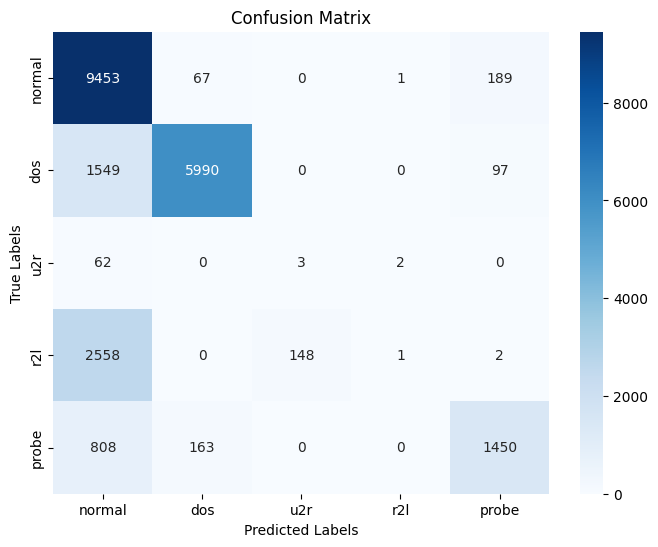

In [27]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb


# Class dictionary for labels
class_dict = {0: "normal", 1: "dos", 2: "u2r", 3: "r2l", 4: "probe"}

# If y_test and y_pred are in string format, convert them to numeric format first
# Example: y_test = ['Normal', 'DoS', 'DoS', 'Normal', 'Probe', ...] --> convert to numbers
label_mapping = {"normal": 0, "dos": 1, "u2r": 2, "r2l": 3, "probe": 4}

# Convert y_test and y_pred to numeric if they are in string format
if isinstance(y_test[0], str):  # Check if y_test is in string format
    y_test_numeric = [label_mapping[label] for label in y_test]
else:
    y_test_numeric = y_test

# Convert y_pred to numeric if it's in string format
if isinstance(y_pred[0], str):  # Check if y_pred is in string format
    y_pred_numeric = [label_mapping[label] for label in y_pred]
else:
    y_pred_numeric = y_pred

# Generate confusion matrix with numeric values
cm = confusion_matrix(y_test_numeric, y_pred_numeric)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[class_dict[i] for i in range(5)], yticklabels=[class_dict[i] for i in range(5)])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
result = random_forest_model.score(x_test, y0_test)
print(result)

accuracy=accuracy_score(y0_test,y_pred)
recall=recall_score(y0_test,y_pred,average='micro')
precision=precision_score(y0_test,y_pred,average='micro')
f1=f1_score(y0_test,y_pred,average='micro')
print("Performance over the testing data set \n")
print("Accuracy : {} , Recall : {} , Precision : {} , F1 : {}\n".format(accuracy,recall,precision,f1 ))

0.753981280220024
Performance over the testing data set 

Accuracy : 0.753981280220024 , Recall : 0.753981280220024 , Precision : 0.753981280220024 , F1 : 0.753981280220024



In [20]:
save_model(random_forest_model, "C:\\Users\\srees\\PycharmProjects\\myProject\\models\\random_forest_model.sav")



NameError: name 'random_forest_model' is not defined

In [ ]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
from sklearn.svm import SVC
# Loading the model
svm_model = SVC(kernel='linear',probability=True)

In [15]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
svm_model.fit(x_train, y0_train)
print("Model has been trained.")

y0_test[10]

svm_model.predict_proba(x_test[10].reshape(1, 122))

Model has been trained.


array([[9.92970549e-01, 1.23569626e-03, 8.74713104e-04, 3.81938875e-03,
        1.09965310e-03]])

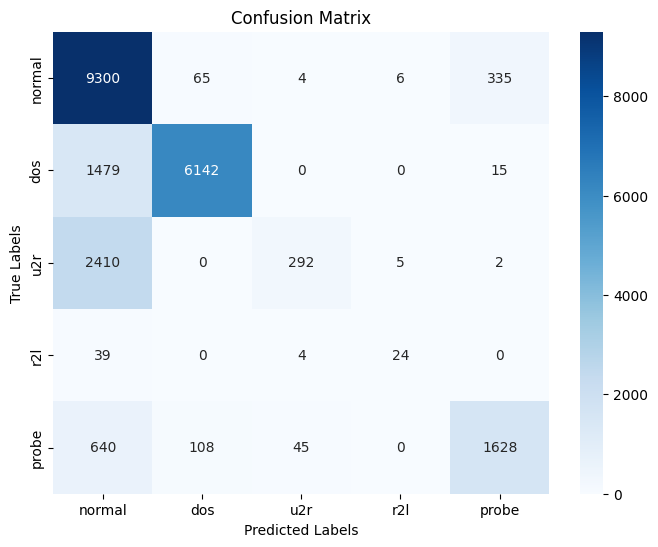

In [ ]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
class_dict = {0: "normal", 1: "dos", 2: "u2r", 3: "r2l", 4: "probe"}

# Label mapping dictionary
label_mapping = {"normal": 0, "dos": 1, "u2r": 2, "r2l": 3, "probe": 4}

# Predict if not already done
y_pred = svm_model.predict(x_test)

# Convert y_test and y_pred to numeric if needed
if isinstance(y0_test, np.ndarray) and y0_test.dtype == 'O':  # Object type (string)
    y0_test_numeric = np.array([label_mapping[label] for label in y0_test])
else:
    y0_test_numeric = y0_test

if isinstance(y_pred, np.ndarray) and y_pred.dtype == 'O':
    y0_pred_numeric = np.array([label_mapping[label] for label in y_pred])
else:
    y0_pred_numeric = y_pred

# Generate confusion matrix
cm = confusion_matrix(y0_test_numeric, y0_pred_numeric)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_dict[i] for i in range(5)],
            yticklabels=[class_dict[i] for i in range(5)])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [19]:
# c:\Users\srees\PycharmProjects\myProject\Untitled.ipynb
result = svm_model.score(x_test, y0_test)
print(result)

accuracy = accuracy_score(y0_test, y_pred)
recall = recall_score(y0_test, y_pred, average='micro')
precision = precision_score(y0_test, y_pred, average='micro')
f1 = f1_score(y0_test, y_pred, average='micro')
print("Performance over the testing data set \n")
print("Accuracy : {}, Recall : {}, Precision : {}, F1 : {}\n".format(accuracy, recall, precision, f1))

0.7712371911458102
Performance over the testing data set 

Accuracy : 0.7712371911458102, Recall : 0.7712371911458102, Precision : 0.7712371911458102, F1 : 0.7712371911458102



In [ ]:
save_model(svm_model, "C:\\Users\\srees\\PycharmProjects\\myProject\\models\\Linear_SVM_model.sav")

Model has been saved at: C:\Users\srees\PycharmProjects\myProject\models\Linear_SVM_model.sav
